In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest

In [2]:
import pandas as pd

demo = pd.read_csv('data/raw/df_final_demo.txt')
experiment = pd.read_csv('data/raw/df_final_experiment_clients.txt')

web_1 = pd.read_csv('data/raw/df_final_web_data_pt_1 .txt')
web_2 = pd.read_csv('data/raw/df_final_web_data_pt_2.txt')

In [3]:
print(demo.shape)
print(experiment.shape)
print(web_1.shape)
print(web_2.shape)

(70609, 9)
(70609, 2)
(343141, 5)
(412264, 5)


In [4]:
demo.head()

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth
0,836976,6.0,73.0,60.5,U,2.0,45105.30,6.0,9.0
1,2304905,7.0,94.0,58.0,U,2.0,110860.30,6.0,9.0
2,1439522,5.0,64.0,32.0,U,2.0,52467.79,6.0,9.0
3,1562045,16.0,198.0,49.0,M,2.0,67454.65,3.0,6.0
4,5126305,12.0,145.0,33.0,F,2.0,103671.75,0.0,3.0


In [5]:
web_1.head()

,client_id,visitor_id,visit_id,process_step,date_time
0,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:27:07
1,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:26:51
2,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:19:22
3,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:19:13
4,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:18:04


In [6]:
experiment.head()

,client_id,Variation
0,9988021,Test
1,8320017,Test
2,4033851,Control
3,1982004,Test
4,9294070,Control


In [7]:
web_2.head()

,client_id,visitor_id,visit_id,process_step,date_time
0,763412,601952081_10457207388,397475557_40440946728_419634,confirm,2017-06-06 08:56:00
1,6019349,442094451_91531546617,154620534_35331068705_522317,confirm,2017-06-01 11:59:27
2,6019349,442094451_91531546617,154620534_35331068705_522317,step_3,2017-06-01 11:58:48
3,6019349,442094451_91531546617,154620534_35331068705_522317,step_2,2017-06-01 11:58:08
4,6019349,442094451_91531546617,154620534_35331068705_522317,step_1,2017-06-01 11:57:58


In [8]:
demo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70609 entries, 0 to 70608
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   client_id         70609 non-null  int64  
 1   clnt_tenure_yr    70595 non-null  float64
 2   clnt_tenure_mnth  70595 non-null  float64
 3   clnt_age          70594 non-null  float64
 4   gendr             70595 non-null  object 
 5   num_accts         70595 non-null  float64
 6   bal               70595 non-null  float64
 7   calls_6_mnth      70595 non-null  float64
 8   logons_6_mnth     70595 non-null  float64
dtypes: float64(7), int64(1), object(1)
memory usage: 4.8+ MB


In [9]:
experiment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70609 entries, 0 to 70608
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   client_id  70609 non-null  int64 
 1   Variation  50500 non-null  object
dtypes: int64(1), object(1)
memory usage: 1.1+ MB


In [10]:
web_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 343141 entries, 0 to 343140
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   client_id     343141 non-null  int64 
 1   visitor_id    343141 non-null  object
 2   visit_id      343141 non-null  object
 3   process_step  343141 non-null  object
 4   date_time     343141 non-null  object
dtypes: int64(1), object(4)
memory usage: 13.1+ MB


In [11]:
print("Demo duplicates:", demo.duplicated().sum())
print("Experiment duplicates:", experiment.duplicated().sum())
print("Web 1 duplicates:", web_1.duplicated().sum())
print("Web 2 duplicates:", web_2.duplicated().sum())

Demo duplicates: 0
Experiment duplicates: 0
Web 1 duplicates: 2095
Web 2 duplicates: 8669


In [12]:
#merge two datasets(pt1 and pt2)
web = pd.concat([web_1, web_2], ignore_index=True)
web.shape

(755405, 5)

In [13]:
web.duplicated().sum()

np.int64(10764)

In [14]:
web = web.drop_duplicates()
web.shape

(744641, 5)

In [15]:
demo.isnull().sum()

client_id            0
clnt_tenure_yr      14
clnt_tenure_mnth    14
clnt_age            15
gendr               14
num_accts           14
bal                 14
calls_6_mnth        14
logons_6_mnth       14
dtype: int64

In [16]:
experiment.isnull().sum()

client_id        0
Variation    20109
dtype: int64

In [17]:
web.isnull().sum()

client_id       0
visitor_id      0
visit_id        0
process_step    0
date_time       0
dtype: int64

In [18]:
demo['gendr'].value_counts(dropna=False)

gendr
U      24122
M      23724
F      22746
NaN       14
X          3
Name: count, dtype: int64

In [19]:
demo = demo[demo['gendr'] != 'X']

In [20]:
#clients without experiment assignment
experiment['Variation'].isnull().sum()

np.int64(20109)

In [21]:
#remove clients with no experiment assignement
experiment = experiment.dropna(subset=['Variation'])

In [22]:
#find numerical variables
demo.describe()

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,num_accts,bal,calls_6_mnth,logons_6_mnth
count,7.060600e+04,70592.000000,70592.000000,70591.000000,70592.000000,7.059200e+04,70592.000000,70592.000000
mean,5.005032e+06,12.053051,150.660684,46.442542,2.255525,1.474503e+05,3.382465,5.566721
std,2.877313e+06,6.871944,82.091315,15.591381,0.534999,3.015141e+05,2.236587,2.353292
min,1.690000e+02,2.000000,33.000000,13.500000,1.000000,1.378942e+04,0.000000,1.000000
25%,2.519367e+06,6.000000,82.000000,32.500000,2.000000,3.734856e+04,1.000000,4.000000
50%,5.017030e+06,11.000000,136.000000,47.000000,2.000000,6.333658e+04,3.000000,5.000000
75%,7.483198e+06,16.000000,192.000000,59.000000,2.000000,1.375487e+05,6.000000,7.000000
max,9.999839e+06,62.000000,749.000000,96.000000,8.000000,1.632004e+07,7.000000,9.000000


In [23]:
#find categorical vaiables

In [24]:
#gender distribution 
demo['gendr'].value_counts(dropna=False)

gendr
U      24122
M      23724
F      22746
NaN       14
Name: count, dtype: int64

In [25]:
#experiment groups
experiment['Variation'].value_counts(dropna=False)

Variation
Test       26968
Control    23532
Name: count, dtype: int64

In [26]:
#process steps
web['process_step'].value_counts()

process_step
start      234999
step_1     162797
step_2     132750
step_3     111589
confirm    102506
Name: count, dtype: int64

In [27]:
#visual EDA

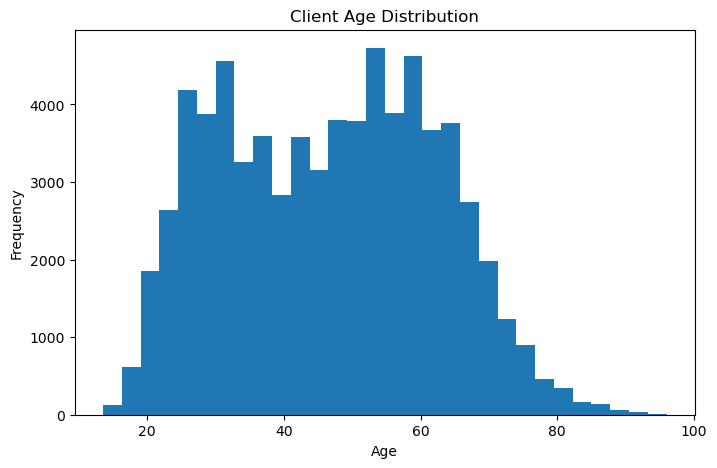

In [28]:
#age distribution 
plt.figure(figsize=(8,5))
plt.hist(demo['clnt_age'].dropna(), bins=30)
plt.title('Client Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

In [29]:
#Age Distribution Insights
#The online process is mainly used by middle-aged and older clients, especially those between 45 and 60 years old.
#Since older users may experience more usability friction, clearer navigation and interface design could improve completion rates and overall user 
#experience.

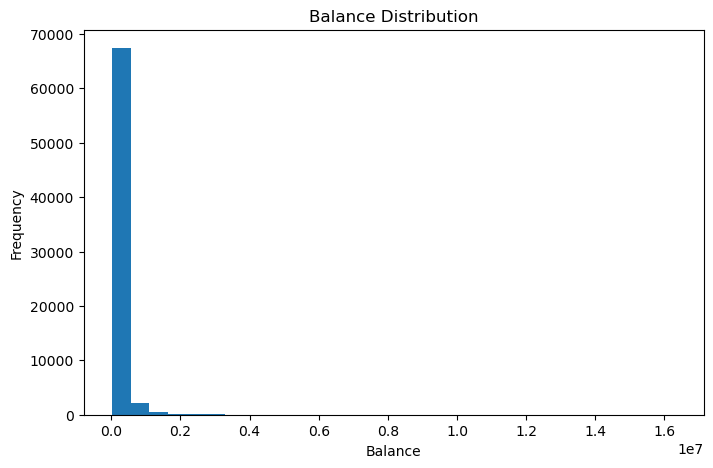

In [30]:
#account balance distribution 
plt.figure(figsize=(8,5))
plt.hist(demo['bal'].dropna(), bins=30)
plt.title('Balance Distribution')
plt.xlabel('Balance')
plt.ylabel('Frequency')
plt.show()

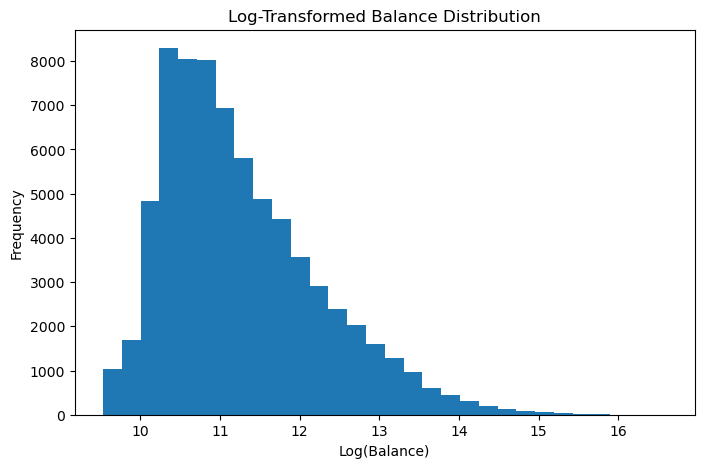

In [31]:
plt.figure(figsize=(8,5))
plt.hist(np.log1p(demo['bal'].dropna()), bins=30)
plt.title('Log-Transformed Balance Distribution')
plt.xlabel('Log(Balance)')
plt.ylabel('Frequency')
plt.show()

In [32]:
#Balance Distribution Insights
#The balance distribution is highly right-skewed. Most clients have moderate balances, while a small number of clients hold very large account balances.
#This suggests Vanguard serves both regular retail investors and some high-value clients

In [33]:
#check unique clients
print("Unique clients in demo:", demo['client_id'].nunique())
print("Unique clients in experiment:", experiment['client_id'].nunique())
print("Unique clients in web:", web['client_id'].nunique())

Unique clients in demo: 70606
Unique clients in experiment: 50500
Unique clients in web: 120157


In [34]:
#convert datetime column
web['date_time'] = pd.to_datetime(web['date_time'])

In [35]:
#check date ranges
print(web['date_time'].min())
print(web['date_time'].max())

2017-03-15 00:03:03
2017-06-20 23:59:57


In [36]:
#session exploration 
web['visitor_id'].nunique()

130236

In [37]:
demo.columns

Index(['client_id', 'clnt_tenure_yr', 'clnt_tenure_mnth', 'clnt_age', 'gendr',
       'num_accts', 'bal', 'calls_6_mnth', 'logons_6_mnth'],
      dtype='object')

In [38]:
#analyse tenure
demo['clnt_tenure_yr'].describe()

count    70592.000000
mean        12.053051
std          6.871944
min          2.000000
25%          6.000000
50%         11.000000
75%         16.000000
max         62.000000
Name: clnt_tenure_yr, dtype: float64

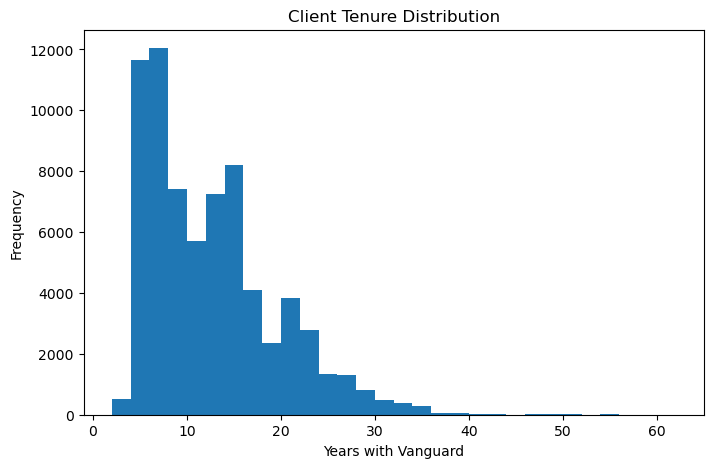

In [39]:
#visualize tenure
plt.figure(figsize=(8,5))
plt.hist(demo['clnt_tenure_yr'].dropna(), bins=30)
plt.title('Client Tenure Distribution')
plt.xlabel('Years with Vanguard')
plt.ylabel('Frequency')
plt.show()

In [40]:
#Client Tenure Insights
#Most users are long-term Vanguard clients, with many having between 5 and 20 years of tenure.
#This suggests the platform is mainly used by experienced and loyal investors, making improvements in the redesigned interface especially meaningful.

In [41]:
#analyze digital activity
demo['logons_6_mnth'].describe()

count    70592.000000
mean         5.566721
std          2.353292
min          1.000000
25%          4.000000
50%          5.000000
75%          7.000000
max          9.000000
Name: logons_6_mnth, dtype: float64

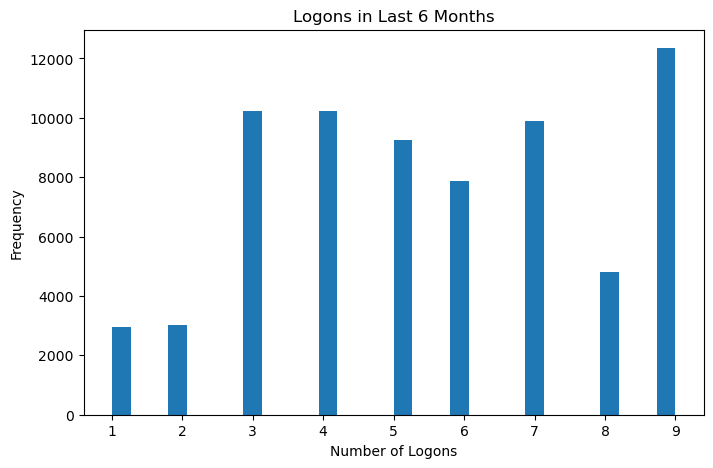

In [42]:
#visualize logoins
plt.figure(figsize=(8,5))
plt.hist(demo['logons_6_mnth'].dropna(), bins=30)
plt.title('Logons in Last 6 Months')
plt.xlabel('Number of Logons')
plt.ylabel('Frequency')
plt.show()

In [43]:
#Digital Engagement Insights

#The logon distribution indicates that many clients interact with Vanguard’s online platform frequently, with most users logging in multiple times 
#during the previous six months.

#This suggests that the experiment primarily involves an already digitally engaged customer base rather than first-time online users. Therefore, 
#improvements in completion behavior are more likely attributable to the redesigned interface itself rather than increased familiarity with digital
#tools.

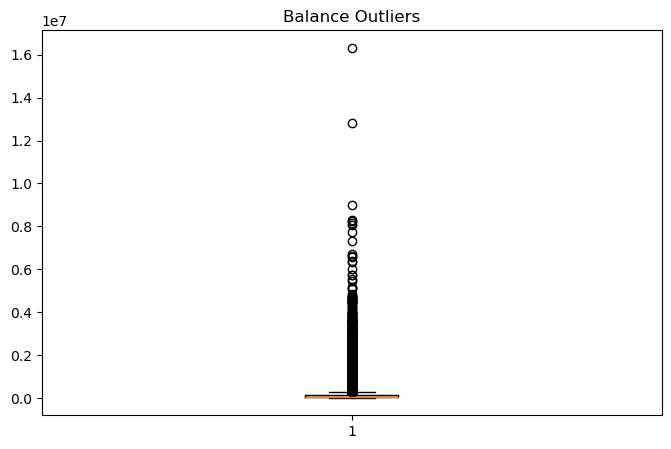

In [44]:
#detect outliers
plt.figure(figsize=(8,5))
plt.boxplot(demo['bal'].dropna())
plt.title('Balance Outliers')
plt.show()

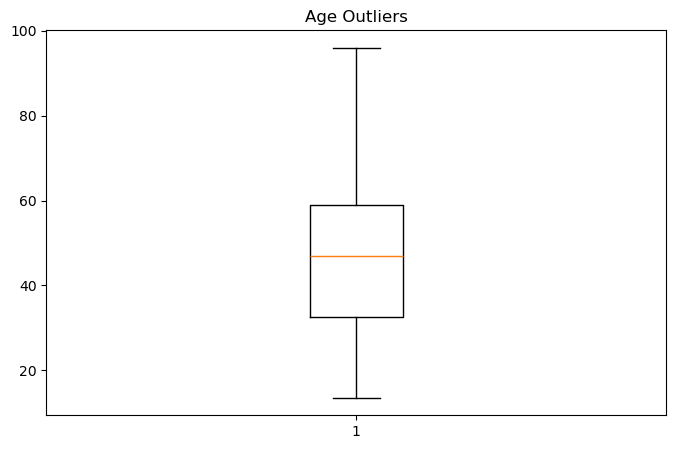

In [45]:
#age outliers
plt.figure(figsize=(8,5))
plt.boxplot(demo['clnt_age'].dropna())
plt.title('Age Outliers')
plt.show()

In [46]:
#balance outliers
Q1 = demo['bal'].quantile(0.25)
Q3 = demo['bal'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
print(lower)
print(upper)

-112951.67000000004
287848.93000000005


In [47]:
outliers = demo[
    (demo['bal'] < lower) |
    (demo['bal'] > upper)
]
outliers.shape

(8018, 9)

In [48]:
demo.describe()

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,num_accts,bal,calls_6_mnth,logons_6_mnth
count,7.060600e+04,70592.000000,70592.000000,70591.000000,70592.000000,7.059200e+04,70592.000000,70592.000000
mean,5.005032e+06,12.053051,150.660684,46.442542,2.255525,1.474503e+05,3.382465,5.566721
std,2.877313e+06,6.871944,82.091315,15.591381,0.534999,3.015141e+05,2.236587,2.353292
min,1.690000e+02,2.000000,33.000000,13.500000,1.000000,1.378942e+04,0.000000,1.000000
25%,2.519367e+06,6.000000,82.000000,32.500000,2.000000,3.734856e+04,1.000000,4.000000
50%,5.017030e+06,11.000000,136.000000,47.000000,2.000000,6.333658e+04,3.000000,5.000000
75%,7.483198e+06,16.000000,192.000000,59.000000,2.000000,1.375487e+05,6.000000,7.000000
max,9.999839e+06,62.000000,749.000000,96.000000,8.000000,1.632004e+07,7.000000,9.000000


In [49]:
#Outlier Analysis

#Outliers were explored using descriptive statistics and boxplots. High balance values were retained because they likely represent real high-value 
#clients rather than data errors. Most variables showed realistic ranges, although a small number of unusually young clients may optionally be 
#excluded from the analysis.

In [50]:
demo.isnull().all(axis=1).sum()

np.int64(0)

In [51]:
experiment.isnull().all(axis=1).sum()

np.int64(0)

In [52]:
web.isnull().all(axis=1).sum()

np.int64(0)

In [53]:
experiment['Variation'].isnull().sum()

np.int64(0)

In [56]:
df = ( web
    .merge(experiment, on='client_id', how='left')
    .merge(demo, on='client_id', how='left'))

In [57]:
df_exp = df[
    df['Variation'].isin(['Control', 'Test'])]

In [58]:
#KPI 1 - Completion Rate ( clients reaching confirm ) 
completion = ( df_exp
    .groupby(['client_id', 'Variation'])['process_step']
    .apply(lambda x: 'confirm' in x.values)
    .reset_index(name='completed'))
completion.head()

,client_id,Variation,completed
0,555,Test,True
1,647,Test,True
2,934,Test,False
3,1028,Control,False
4,1104,Control,False


In [59]:
#Completion Rate by Group
completion_rate = (completion
    .groupby('Variation')
    .agg(
        total_clients=('client_id', 'nunique'),
        completed_clients=('completed', 'sum')
    ).reset_index())

completion_rate['completion_rate'] = (
    completion_rate['completed_clients']
    / completion_rate['total_clients'])
completion_rate

,Variation,total_clients,completed_clients,completion_rate
0,Control,23532,15434,0.655873
1,Test,26968,18687,0.692932


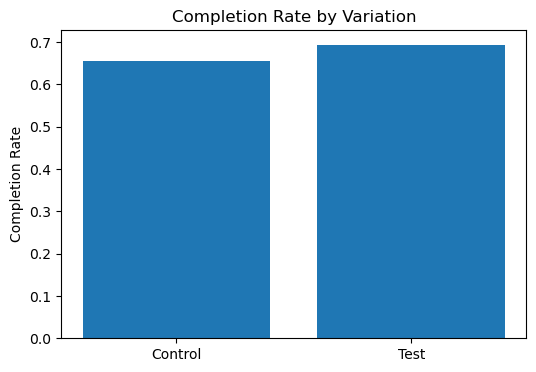

In [60]:
#Visualize Completion Rate 
plt.figure(figsize=(6,4))
plt.bar(
    completion_rate['Variation'],
    completion_rate['completion_rate'])
plt.title('Completion Rate by Variation')
plt.ylabel('Completion Rate')
plt.show()

In [61]:
#KPI 2 — Time Spent on Each Step ( seconds between consecutive events in same visit) 
#sort 
df_exp = df_exp.sort_values( ['client_id', 'visit_id', 'date_time'])

In [62]:
#calculate step duration 
df_exp['next_time'] = (df_exp
    .groupby(['client_id', 'visit_id'])['date_time']
    .shift(-1))
df_exp['step_duration_sec'] = (df_exp['next_time'] - df_exp['date_time']).dt.total_seconds()

In [63]:
#Remove Negative / Extreme Durations
df_exp = df_exp[(df_exp['step_duration_sec'] >= 0) &(df_exp['step_duration_sec'] <= 1800)]

In [64]:
#Average Time Per Step
step_time = (df_exp
    .groupby(['Variation', 'process_step'])
    .agg(avg_time_sec=('step_duration_sec', 'mean') ).reset_index())
step_time

,Variation,process_step,avg_time_sec
0,Control,confirm,145.541732
1,Control,start,60.881279
2,Control,step_1,47.460199
3,Control,step_2,90.175377
4,Control,step_3,133.298306
5,Test,confirm,217.719822
6,Test,start,56.257391
7,Test,step_1,58.483000
8,Test,step_2,88.106906
9,Test,step_3,124.820947


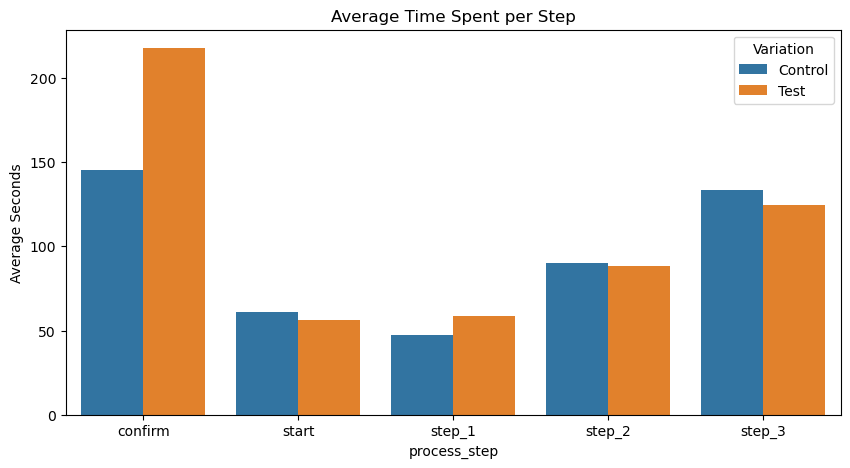

In [66]:
#Visualize Step Duration
import seaborn as sns
plt.figure(figsize=(10,5))
sns.barplot( data=step_time, x='process_step', y='avg_time_sec', hue='Variation')
plt.title('Average Time Spent per Step')
plt.ylabel('Average Seconds')
plt.show()

In [67]:
#KPI 3 — Error Rate (Backtracking, step visits where users moved to a previous step ) 
#define step order 
step_order = {'start': 0, 'step_1': 1, 'step_2': 2, 'step_3': 3, 'confirm': 4}

In [68]:
#convert steps to numeric
df_exp['step_num'] = (df_exp['process_step'].map(step_order))

In [70]:
df_exp['previous_step'] = (df_exp
    .groupby(['client_id', 'visit_id'])['step_num']
    .shift(1))
df_exp['backtrack'] = ( df_exp['step_num'] < df_exp['previous_step'])

In [71]:
#error rate by group
error_rate = (df_exp
    .groupby('Variation')
    .agg(
        total_actions=('backtrack', 'count'),
        backtracks=('backtrack', 'sum') ) .reset_index())
error_rate['error_rate'] = (error_rate['backtracks']/ error_rate['total_actions'])
error_rate

,Variation,total_actions,backtracks,error_rate
0,Control,108147,7690,0.071107
1,Test,139292,12206,0.087629


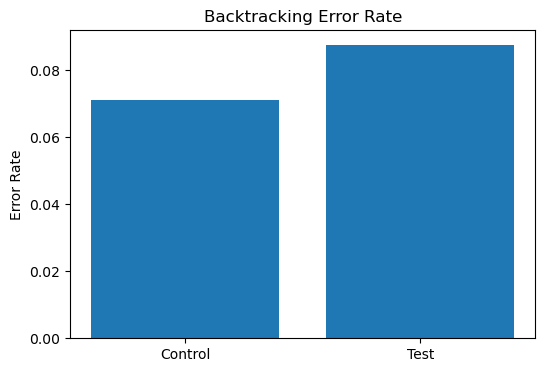

In [72]:
#Visualize error rate 
plt.figure(figsize=(6,4))
plt.bar(error_rate['Variation'],error_rate['error_rate'])
plt.title('Backtracking Error Rate')
plt.ylabel('Error Rate')
plt.show()

In [ ]:
#KPI 4 - Drop off Rate ( % of users who started but did not confirm or lost between each consecutive step)

In [ ]:
#KPI 5 - Repeat Step Rate (users repeating the same step multiple times) could indicate confusion, unclear instructions and technical friction

In [ ]:
#KPI 6  - Repeat visit Rate ( % of clients with more than 1 visit session ) 